# Exact elimination and the mini-bucket tradeoff

This notebook makes the central compromise of approximate dynamic programming explicit. Exact bucket elimination preserves every interaction created by marginalization. Mini-bucket elimination limits factor scope and therefore computational cost, but replaces exact summation by a certified upper bound.

We use a positive binary factor graph on six variables. The exact partition function is available by enumeration, which lets us verify every bound.

In [1]:
CHAPTER_DIR = "ch07"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

CWD = Path.cwd()
if CWD.name.startswith("ch"):
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / CHAPTER_DIR
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(577)
NODE_COLOR = "#34495e"
NODE_TEXT_COLOR = "white"
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})

def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 240})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


## Model and reusable factor operations

A factor is stored as a table together with an ordered scope. Eliminating $x_i$ multiplies all factors containing $x_i$ and sums over that variable.

In [2]:
from itertools import product

class Factor:
    def __init__(self, scope, values):
        self.scope=tuple(scope); self.values=np.asarray(values,dtype=float)
    def align(self, union):
        shape=[1]*len(union)
        perm=[]
        for s in self.scope:
            perm.append(union.index(s))
        arr=self.values
        # move current axes to their positions by expanding then transpose
        for j,u in enumerate(union):
            if u not in self.scope: arr=np.expand_dims(arr,axis=-1)
        current=list(self.scope)+[u for u in union if u not in self.scope]
        arr=np.transpose(arr,[current.index(u) for u in union])
        return arr

def multiply(factors):
    union=[]
    for f in factors:
        for s in f.scope:
            if s not in union: union.append(s)
    out=np.ones([2]*len(union))
    for f in factors: out*=f.align(union)
    return Factor(union,out)

def sum_out(f,var):
    axis=f.scope.index(var)
    return Factor([s for s in f.scope if s!=var],f.values.sum(axis=axis))

def max_out(f,var):
    axis=f.scope.index(var)
    return Factor([s for s in f.scope if s!=var],f.values.max(axis=axis))

n=6
edges=[(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(0,3)]
h=np.array([.20,-.12,.10,.05,-.08,.15])
J={(0,1):.55,(1,2):-.42,(2,3):.48,(3,4):.38,(4,5):-.35,(5,0):.45,(0,3):.30}
factors=[]
for i in range(n):
    xs=np.array([-1,1]); factors.append(Factor([i],np.exp(h[i]*xs)))
for (i,j),v in J.items():
    xs=np.array([-1,1]); factors.append(Factor([i,j],np.exp(v*np.outer(xs,xs))))

configs=np.array(list(product([-1,1],repeat=n)))
weights=[]
for x in configs:
    e=np.dot(h,x)+sum(v*x[i]*x[j] for (i,j),v in J.items())
    weights.append(np.exp(e))
Z_exact=float(np.sum(weights)); print('Exact Z =',Z_exact)

Exact Z = 119.93937830459446


## Exact bucket elimination and induced width

The largest intermediate scope determines the exponential cost. Different orders can give different induced widths even though they return the same $Z$.

,order,Z,induced width
0,around cycle,119.939378,3
1,chord endpoints late,119.939378,2
2,chord endpoints early,119.939378,4


Saved: figs/ch07_01_graph_and_induced_width.pdf


Saved: figs/ch07_01_graph_and_induced_width.png


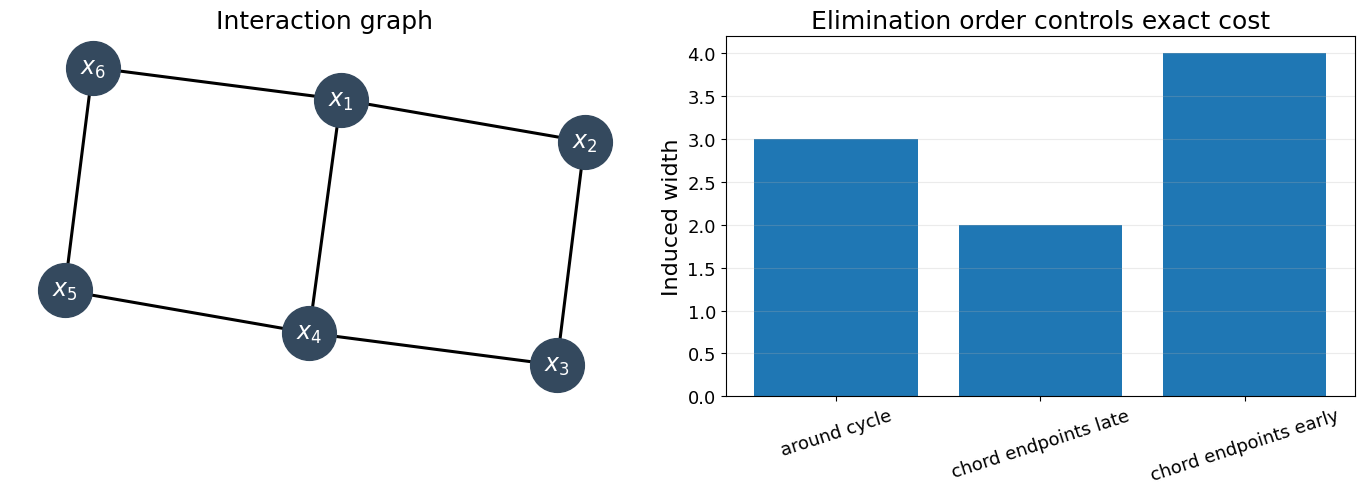

In [3]:
def bucket_eliminate(factors,order):
    fs=[Factor(f.scope,f.values.copy()) for f in factors]
    max_scope=0; history=[]
    for v in order:
        bucket=[f for f in fs if v in f.scope]
        fs=[f for f in fs if v not in f.scope]
        joint=multiply(bucket); max_scope=max(max_scope,len(joint.scope))
        history.append((v,len(joint.scope),joint.scope))
        fs.append(sum_out(joint,v))
    z=multiply(fs).values.item()
    return z,max_scope-1,history
orders={'around cycle':[0,1,2,3,4,5],'chord endpoints late':[1,2,4,5,0,3], 'chord endpoints early':[0,3,1,2,4,5]}
rows=[]
for name,o in orders.items():
    z,w,hist=bucket_eliminate(factors,o); rows.append((name,z,w))
summary=pd.DataFrame(rows,columns=['order','Z','induced width']); display(summary)
assert np.allclose(summary['Z'],Z_exact)

G=nx.Graph(edges); pos=nx.spring_layout(G,seed=7)
fig,axes=plt.subplots(1,2,figsize=(14,5.2))
nx.draw_networkx_nodes(G,pos,node_size=1500,node_color=NODE_COLOR,ax=axes[0])
nx.draw_networkx_labels(G,pos,labels={i:rf'$x_{i+1}$' for i in range(n)},font_color='white',font_size=17,ax=axes[0])
nx.draw_networkx_edges(G,pos,width=2.2,ax=axes[0]); axes[0].set_title('Interaction graph'); axes[0].axis('off')
axes[1].bar(summary['order'],summary['induced width']); axes[1].set_ylabel('Induced width'); axes[1].tick_params(axis='x',rotation=18); axes[1].set_title('Elimination order controls exact cost'); axes[1].grid(axis='y',alpha=.25)
fig.tight_layout(); save_figure(fig,'ch07_01_graph_and_induced_width'); plt.show()

## Mini-bucket upper bounds

We partition each bucket greedily so that every mini-bucket joint scope has at most $i+1$ variables. One mini-bucket is summed; the others are maximized. This is the zero-weight limit of weighted mini-bucket elimination and gives an upper bound.

,ibound,upper bound,relative gap
0,1,257.999209,1.151080e+00
1,2,189.911502,5.833958e-01
2,3,119.939378,-2.220446e-16
3,4,119.939378,-2.220446e-16
4,5,119.939378,-2.220446e-16


Saved: figs/ch07_01_mbe_bound_vs_ibound.pdf
Saved: figs/ch07_01_mbe_bound_vs_ibound.png


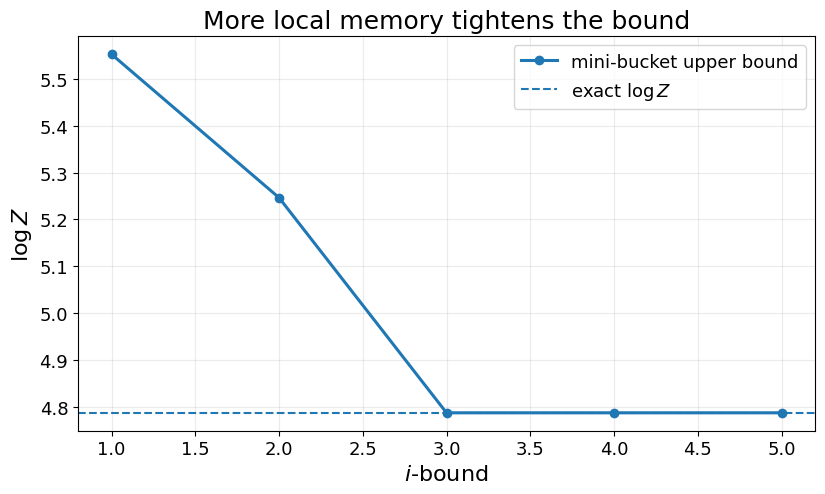

In [4]:
def partition_bucket(bucket,var,ibound):
    groups=[]
    for f in sorted(bucket,key=lambda q:len(q.scope),reverse=True):
        placed=False
        for g in groups:
            scope=set().union(*(set(q.scope) for q in g+[f]))
            if len(scope)<=ibound+1: g.append(f); placed=True; break
        if not placed: groups.append([f])
    return groups

def mbe(factors,order,ibound):
    fs=[Factor(f.scope,f.values.copy()) for f in factors]
    for v in order:
        bucket=[f for f in fs if v in f.scope]; fs=[f for f in fs if v not in f.scope]
        groups=partition_bucket(bucket,v,ibound)
        for k,g in enumerate(groups):
            joint=multiply(g)
            fs.append(sum_out(joint,v) if k==len(groups)-1 else max_out(joint,v))
    return multiply(fs).values.item()

order=orders['around cycle']
bounds=[]
for ib in range(1,6): bounds.append((ib,mbe(factors,order,ib)))
bdf=pd.DataFrame(bounds,columns=['ibound','upper bound']); bdf['relative gap']=bdf['upper bound']/Z_exact-1; display(bdf)
assert np.all(bdf['upper bound']>=Z_exact-1e-10)
fig,ax=plt.subplots(figsize=(8.5,5.2)); ax.plot(bdf['ibound'],np.log(bdf['upper bound']),marker='o',linewidth=2.2,label='mini-bucket upper bound'); ax.axhline(np.log(Z_exact),linestyle='--',label='exact $\\log Z$'); ax.set_xlabel('$i$-bound'); ax.set_ylabel('$\\log Z$'); ax.set_title('More local memory tightens the bound'); ax.legend(); ax.grid(alpha=.25); fig.tight_layout(); save_figure(fig,'ch07_01_mbe_bound_vs_ibound'); plt.show()

## Stress test: a fixed $i$-bound can become uninformative as interactions strengthen

The $i$-bound controls memory, not problem difficulty. A bound that is tight for weak interactions can become loose when the same graph develops stronger correlations. To separate these effects, we hold the graph, elimination order, and $i$-bound fixed while multiplying every field and coupling by a common scale.

This is the appropriate way to read approximation plots throughout the book: a resource parameter should be tested not only at one benign instance but along a hardness direction until the approximation visibly degrades.

Saved: figs/ch07_01_mbe_stress_test.pdf


Saved: figs/ch07_01_mbe_stress_test.png


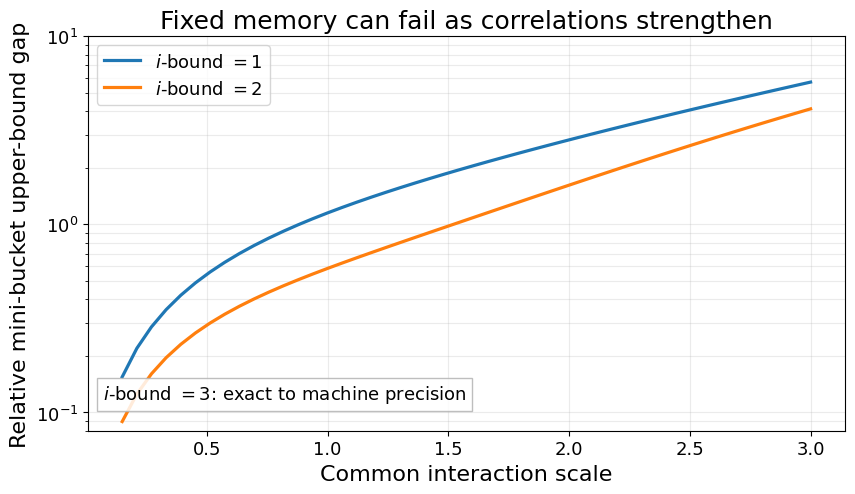

In [5]:
def scaled_factors(scale):
    fs = []
    xs = np.array([-1, 1])
    for i in range(n):
        fs.append(Factor([i], np.exp(scale * h[i] * xs)))
    for (i, j), value in J.items():
        fs.append(Factor([i, j], np.exp(scale * value * np.outer(xs, xs))))
    return fs

interaction_scale = np.linspace(0.15, 3.0, 48)
stress_rows = []
fixed_ibounds = [1, 2, 3]
for scale in interaction_scale:
    fs = scaled_factors(scale)
    exact_scale, _, _ = bucket_eliminate(fs, order)
    row = [scale, exact_scale]
    for ib in fixed_ibounds:
        row.append(mbe(fs, order, ib) / exact_scale - 1)
    stress_rows.append(row)
stress = np.asarray(stress_rows)

fig, ax = plt.subplots(figsize=(8.8, 5.2))
for ib, col in [(1, 2), (2, 3)]:
    ax.semilogy(interaction_scale, stress[:, col], linewidth=2.3, label=rf"$i$-bound $={ib}$")
ax.set_ylim(8e-2, 10)
ax.set_xlabel("Common interaction scale")
ax.set_ylabel("Relative mini-bucket upper-bound gap")
ax.set_title("Fixed memory can fail as correlations strengthen")
ax.grid(True, which="both", alpha=0.25)
ax.legend(loc="upper left")
ax.text(0.02, 0.08, r"$i$-bound $=3$: exact to machine precision", transform=ax.transAxes,
        fontsize=13, bbox=dict(facecolor="white", alpha=0.85, edgecolor="0.7"))
fig.tight_layout()
save_figure(fig, "ch07_01_mbe_stress_test")
plt.show()


## Exercises

1. Change the chord coupling and identify when the best elimination order changes.
2. Implement a lower bound by replacing the auxiliary maxima by minima.
3. Compare greedy mini-bucket partitioning with random partitions of the same $i$-bound.
4. Record both runtime and bound gap as the number of variables increases.